# EDA и построение признаков

Цель этого ноутбука — изучить исходные сигналы сцинтилляционного детектора, проверить масштаб данных, форму импульсов и подготовить признаки для дальнейшей кластеризации.

## План анализа

1. Загрузить исходные 23 479 сигналов.
2. Проверить размерность, пропуски и базовую статистику.
3. Посмотреть форму случайных импульсов.
4. Построить физически интерпретируемые признаки: площадь, пик, PSD, центр масс и PCA формы.
5. Оценить распределения и взаимосвязи признаков.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from final_solution import RANDOM_STATE, build_base_features, build_features, load_raw

sns.set_theme(style="whitegrid")
DATA_PATH = Path("Run200_Wave_0_1.txt")

## Загрузка данных

Исходный файл содержит служебные колонки и 500 отсчётов формы сигнала. Для анализа отделяются метаданные и сама временная форма импульса.

In [2]:
metadata, signals = load_raw(DATA_PATH)

print("metadata:", metadata.shape)
print("signals:", signals.shape)
print("missing values:", np.isnan(signals).sum())

pd.DataFrame(metadata).describe().T

metadata: (23479, 4)
signals: (23479, 500)
missing values: 0


,count,mean,std,min,25%,50%,75%,max
0,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
3,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02


### Вывод по загрузке

Размер выборки соответствует условию задачи. Пропусков в матрице сигналов нет, поэтому отдельная обработка отсутствующих значений не требуется.

## Визуальный анализ сигналов

На графике ниже показаны случайные импульсы после грубой оценки baseline. Это помогает проверить положение пика, шум до импульса и длину хвоста.

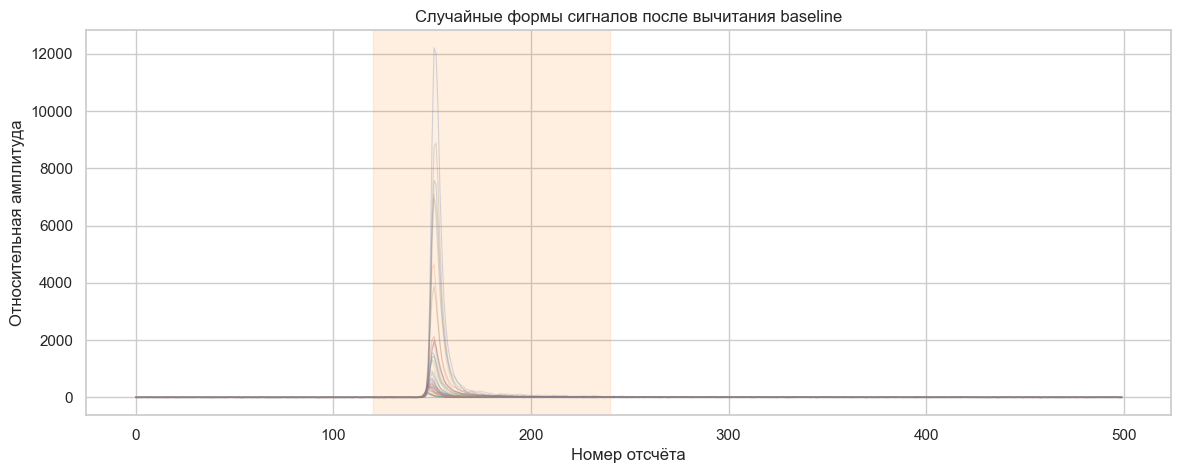

In [3]:
sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(signals), 80, replace=False)
sample = signals[sample_idx]
baseline = np.median(sample[:, :120], axis=1)
positive = baseline[:, None] - sample

plt.figure(figsize=(14, 5))
for row in positive[:45]:
    plt.plot(row, alpha=0.25, linewidth=0.8)
plt.axvspan(120, 240, color="tab:orange", alpha=0.12)
plt.title("Случайные формы сигналов после вычитания baseline")
plt.xlabel("Номер отсчёта")
plt.ylabel("Относительная амплитуда")
plt.show()

### Наблюдения по форме

Основная область пика находится примерно после 120-го отсчёта. До импульса виден участок, пригодный для оценки baseline и шума. Хвост сигнала различается между событиями, поэтому PSD-признаки должны быть полезны для разделения классов.

## Feature Engineering

Используются признаки, которые связаны с физикой импульса: полная площадь, амплитуда, доля хвоста, быстрый компонент, центр масс и PCA-компоненты выровненной формы.

In [4]:
features = build_features(signals, metadata)
base_features = build_base_features(signals)

display(features.head())
display(features.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

,log_charge,log_charge_main,log_peak,peak,peak_idx,psd_fixed,psd_rel,fast_rel,centroid,noise,baseline,expected_frac,meta_1,meta_2,shape_pc_1,shape_pc_2,shape_pc_3,shape_pc_4,shape_pc_5,shape_pc_6
0,8.399760,8.339262,6.023932,412.2,150,0.191451,0.166860,0.833140,168.992351,2.760724,14820.0,0.889928,357.0,113.0,1.546044,1.149579,1.331743,0.659315,0.440216,-1.202430
1,9.433084,9.402447,7.324490,1516.0,151,0.077077,0.062566,0.937434,160.659437,2.674520,14823.0,0.931209,740.0,359.0,-3.366461,-0.372735,0.469710,-0.342392,-0.200589,-0.109361
2,9.742203,9.720526,7.646449,2092.2,151,0.056992,0.047125,0.952875,158.615805,2.455592,14822.0,0.950839,162.0,499.0,-3.955678,-0.358551,0.304448,-0.489713,-0.411443,0.235406
3,8.482602,8.412499,6.130792,458.8,150,0.184510,0.155623,0.844377,171.333195,2.745906,14823.0,0.856778,841.0,123.0,1.482258,0.883148,0.298995,-0.525782,0.278501,-0.573942
4,9.365890,9.348623,7.275034,1442.8,151,0.056497,0.042131,0.957869,157.112994,2.695044,14821.0,0.961095,412.0,348.0,-4.160858,-0.416203,1.305444,0.050730,0.030377,0.374794


,count,mean,std,min,1%,5%,50%,95%,99%,max
log_charge,23479.0,8.864224e+00,1.132276,6.688355,7.016610,7.232010,8.761393,10.791920,11.197834,11.633833
log_charge_main,23479.0,8.794393e+00,1.172433,6.580639,6.840311,7.068172,8.705000,10.768411,11.178617,11.621017
log_peak,23479.0,6.571406e+00,1.233466,4.510860,4.593098,4.741448,6.489205,8.662782,9.103689,9.531380
peak,23479.0,1.484950e+03,1934.030004,90.000000,97.800000,113.600000,657.000000,5782.600000,8987.392000,13784.600000
peak_idx,23479.0,1.501083e+02,1.306976,146.000000,147.000000,148.000000,150.000000,152.000000,152.000000,153.000000
psd_fixed,23479.0,1.479386e-01,0.065659,0.038055,0.051012,0.055285,0.158101,0.252575,0.289389,0.367809
psd_rel,23479.0,1.272595e-01,0.062135,0.028007,0.038741,0.042421,0.131806,0.233758,0.274413,0.359624
fast_rel,23479.0,8.727405e-01,0.062135,0.640376,0.725587,0.766242,0.868194,0.957579,0.961259,0.971993
centroid,23479.0,1.691270e+02,9.292919,154.743658,156.529210,157.150649,167.884258,187.141125,193.835143,212.455154
noise,23479.0,2.700800e+00,0.176911,2.013841,2.314036,2.424642,2.697684,2.985901,3.111318,10.093972


## Распределения признаков

Проверяются признаки, которые дальше используются в моделях. Особое внимание уделяется `log_charge`, `log_peak`, `psd_rel`, `centroid` и первым PCA-компонентам формы.

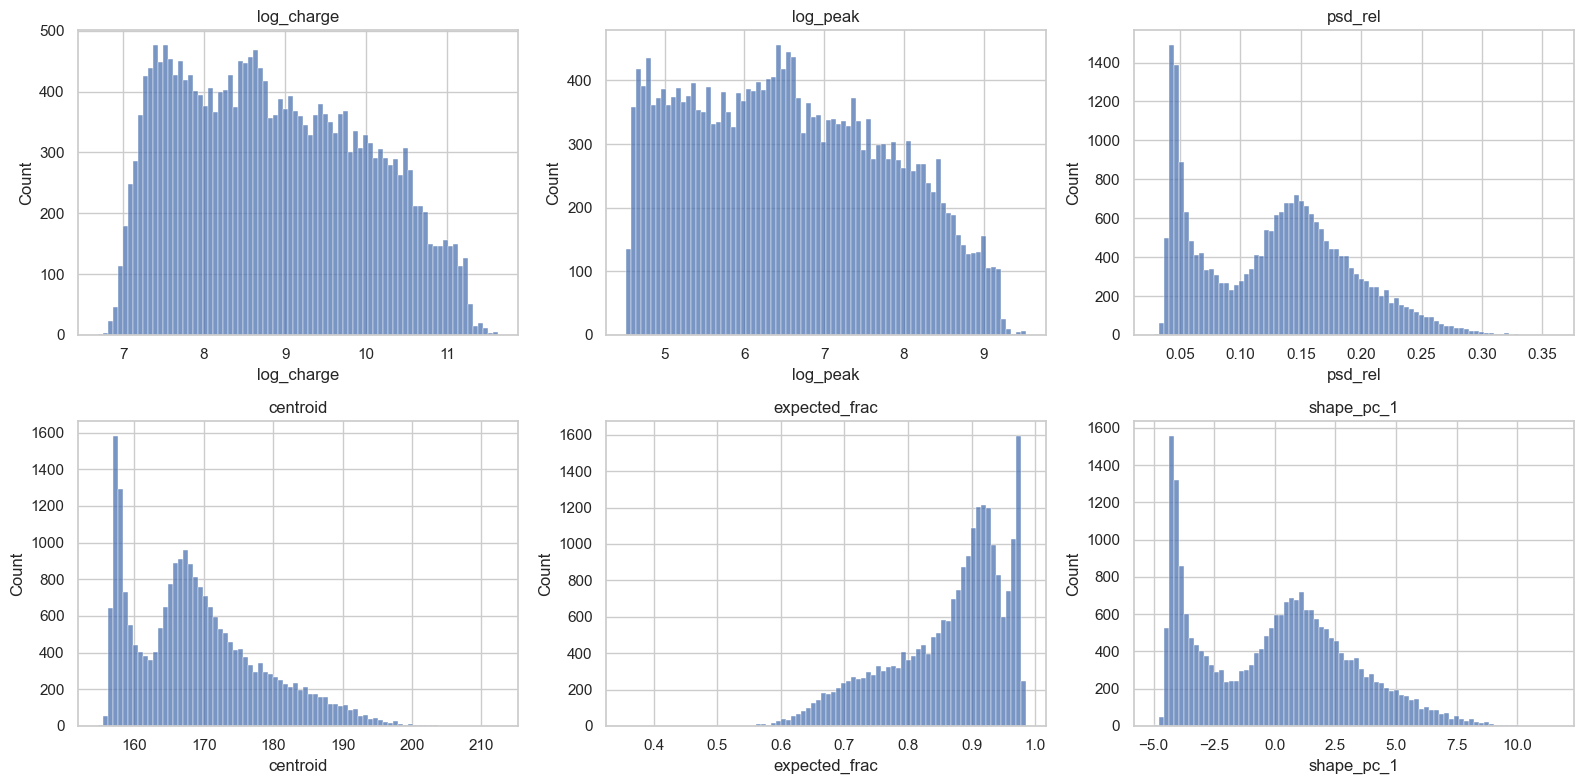

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
columns = ["log_charge", "log_peak", "psd_rel", "centroid", "expected_frac", "shape_pc_1"]
for ax, column in zip(axes.ravel(), columns):
    sns.histplot(features[column], bins=80, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

## Связи между признаками

Корреляционная матрица показывает, какие признаки дублируют друг друга, а какие добавляют независимую информацию о форме сигнала.

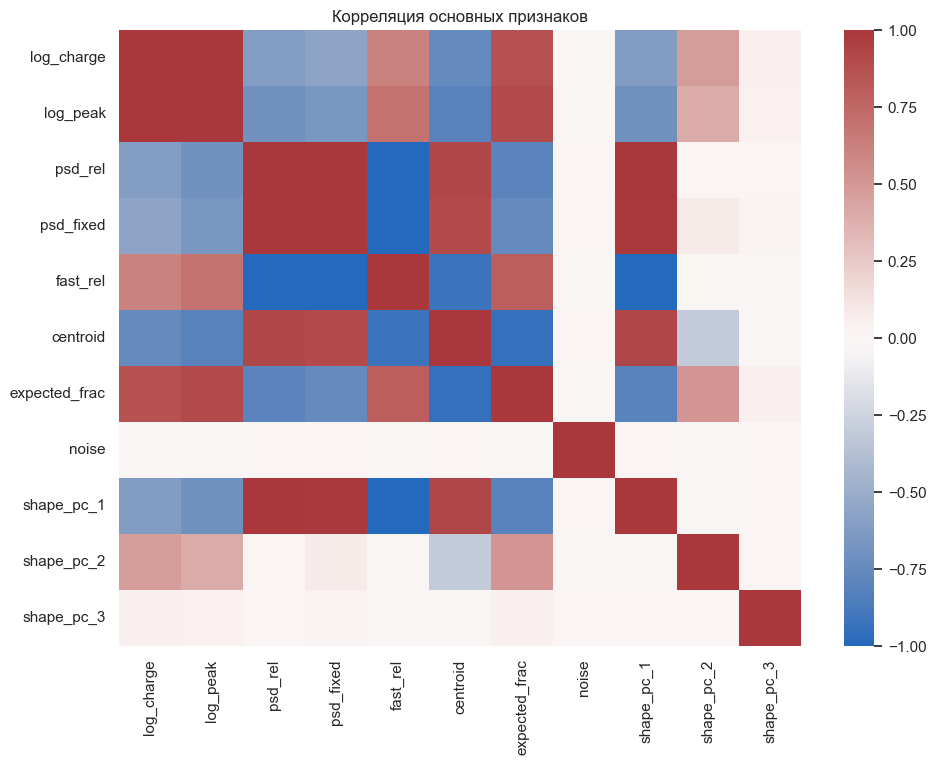

In [6]:
corr_columns = [
    "log_charge",
    "log_peak",
    "psd_rel",
    "psd_fixed",
    "fast_rel",
    "centroid",
    "expected_frac",
    "noise",
    "shape_pc_1",
    "shape_pc_2",
    "shape_pc_3",
]

plt.figure(figsize=(11, 8))
sns.heatmap(features[corr_columns].corr(), cmap="vlag", center=0, annot=False)
plt.title("Корреляция основных признаков")
plt.show()

## Проверка выбросов

Вместо удаления крайних событий они сохраняются в выборке, потому что третий кластер по условию как раз должен собирать неоднозначные и аномальные сигналы.

In [7]:
outlier_columns = ["log_charge", "log_peak", "psd_rel", "noise"]
outlier_report = pd.DataFrame({
    "feature": outlier_columns,
    "q01": [features[col].quantile(0.01) for col in outlier_columns],
    "q99": [features[col].quantile(0.99) for col in outlier_columns],
    "min": [features[col].min() for col in outlier_columns],
    "max": [features[col].max() for col in outlier_columns],
})

display(outlier_report)

,feature,q01,q99,min,max
0,log_charge,7.016610,11.197834,6.688355,11.633833
1,log_peak,4.593098,9.103689,4.510860,9.531380
2,psd_rel,0.038741,0.274413,0.028007,0.359624
3,noise,2.314036,3.111318,2.013841,10.093972


## Итоги EDA

1. Данные не требуют удаления пропусков.
2. Форма хвоста и PSD-признаки являются ключевыми для разделения сигналов.
3. Крайние наблюдения не удаляются, так как они могут соответствовать аномальному кластеру.
4. Для моделирования используются как физические признаки импульса, так и PCA-компоненты выровненной формы.